# (1) ABCD Graphs with the Python implementation

We use the Python implementation of ABCD: ```pip install abcd-graph```

We illustrate the following:
* generate and visualize a few small ABCD graphs with various noise ($\xi$) parameter values
* generate a larger ABCD graph and look at the degree and community size distribution
* use ABCD to generate several graphs to compare graph clustering algorithms

The main functions are:
* **ABCDParams** : specify the parameters for ABCD
* **ABCDGraph(params).build()** : generate the ABCD graph
* Graph.**exporter.to_igraph**() : export to igraph format

NB: Later in this notebook, we show how to use the **Julia** version of ABCD


In [1]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
%matplotlib inline
from collections import Counter
import partition_igraph
from sklearn.metrics import adjusted_mutual_info_score as AMI
from abcd_graph import ABCDGraph, ABCDParams


## (1.1) Small ABCD graphs with 100 nodes and varying $\xi$

The ABCD parameters used to generate those graphs are: 
* $n=100$ (number of nodes)
* $\gamma=2.5$ (a.k.a. as 't1')
* degree range [5,15]
* $\beta=1.5$ (a.k.a. as 't2')
* community size range [30,40]
* $\xi \in \{0.1, 0.2, 0.3, 0.4\}$

In [2]:
## Parameters

## number of nodes
n = 100

## degree distribution
gamma = 2.5 ## a.k.a. t1
delta = 5
Delta = 15

## community sizes distribution
beta = 1.5 ## a.k.a. t2
s = 30
S = 40


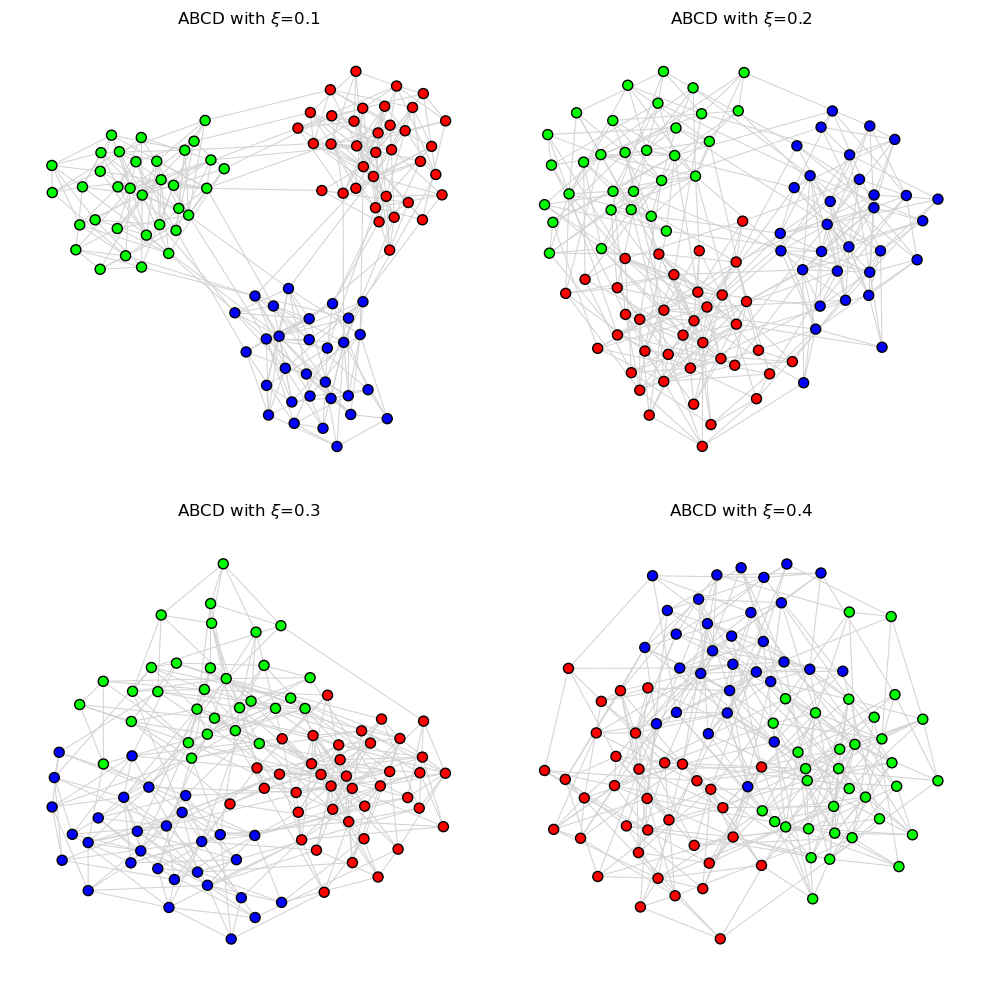

In [3]:
## Noise parameter values
xi_values = [0.1,0.2,0.3,0.4]

fig, axs = plt.subplots(2, 2, figsize=(10, 10)) # You can adjust figsize as needed

## for reproducibility
random.seed(123)
np.random.seed(123)

for i in range(4):
    params = ABCDParams( vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                        min_community_size=s, max_community_size=S, xi=xi_values[i])
    g = ABCDGraph(params).build()
    g_abcd = g.exporter.to_igraph()

    g_abcd.vs['size'] = 10
    g_abcd.es['width'] = .75
    g_abcd.es['color'] = 'lightgrey'
    pal = ig.RainbowPalette(n=max(g_abcd.vs['ground_truth_community'])+1)
    g_abcd.vs['color'] = [pal[i] for i in g_abcd.vs['ground_truth_community']]
    ly = g_abcd.layout_fruchterman_reingold()
    ig.plot(g_abcd, target=axs[i//2,i%2], layout=ly, bbox=(0,0,400,300), Caption="Graph"+str(i))
    axs[i//2,i%2].set_title(r"ABCD with $\xi$="+str(xi_values[i]))
plt.tight_layout()
plt.show()

## (1.2) Larger ABCD graph - looking at degree and community size distributions

The ABCD parameters used to generate this graph: 
* $n=1000000$ (number of nodes)
* $\gamma=2.5$ (a.k.a. as 't1')
* degree range [5,250]
* $\beta=1.5$ (a.k.a. as 't2')
* community size range [500,10000]
* $\xi = 0.2$

In [4]:
## Parameters

## number of nodes
n = 1000000

## degree distribution
gamma = 2.5
delta = 5
Delta = 250

## community sizes distribution
beta = 1.5
s = 500
S = 10000

## noise parameter
xi = 0.2

## for reproducibility
random.seed(321)
np.random.seed(321)

params = ABCDParams(vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                    min_community_size=s, max_community_size=S, xi=xi)
g = ABCDGraph(params).build()
g_abcd = g.exporter.to_igraph()


min degree: 5 ; mean degree: 11.75439 ; max degree: 250


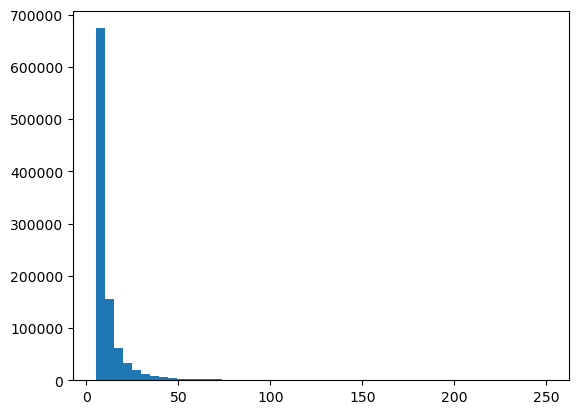

In [5]:
## degree distribution
D = g_abcd.degree()
print('min degree:',np.min(D),'; mean degree:',np.mean(D),'; max degree:',np.max(D))
plt.hist(g_abcd.degree(), bins=50);


min size: 503 ; mean size: 2070.3933747412007 ; max size: 9859


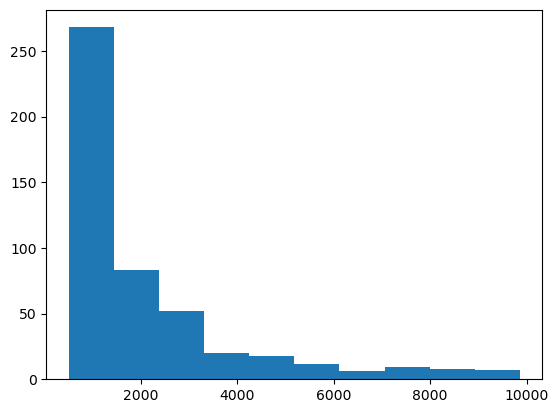

In [6]:
## community size distribution
C = list(Counter(g_abcd.vs['ground_truth_community']).values())
print('min size:',np.min(C),'; mean size:',np.mean(C),'; max size:',np.max(C))
plt.hist(C, bins=10);


## (1.3) ABCD with varying $\xi$ -- experiment with clustering algorithms

Here we show a typical way to compare graph clustering algorithms using ABCD graphs. 
We fix all other parameters while we vary the noise parameter $\xi$. 

For each choice of $\xi$, we generate several graphs, apply several different clustering algorithms,
and compute the AMI (adjusted mutual information) for each algorithm when comparing with the ground-truth communities.

Parameters for the ABCD benchmark graphs are:

* $n=1,000$
* $\gamma=2.5$ (a.k.a. as 't1')
* $\beta=1.5$ (a.k.a. as 't2')
* degree range [10,50]
* community size range [50,100]
* $0.3 \le \xi \le 0.8$


In the first plot below, we show the **mean** AMI values over the repeated tests. We see good results with Infomap, and slightly better results with Leiden and ECG. Label propagation is a fast algortihm, but it does collapse under moderate to high level of noise.

In the second plot, we show the **standard deviations** of the repeated tests. We see higher variability around the value(s) for $\xi$ where the different algorithms start to collapse.

Such studies are useful to compare algorithms; using ABCD, we can directly control parameters such as the noise level.


In [7]:
%%time

## number of nodes
n = 1000

## degrees
gamma = 2.5
delta = 10
Delta = 50

## communities
beta = 1.5
s = 50
S = 100

## generate the graphs and run various clustering algorithms
random.seed(1234)
np.random.seed(1234)

## reduce the number of repeats for a faster run
REP = 5

## Loop and store results
L = []
for xi in np.arange(.3,.801,.05):
    for rep in range(REP):
        
        params = ABCDParams(vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                            min_community_size=s, max_community_size=S, xi=xi)
        g = ABCDGraph(params).build()
        G = g.exporter.to_igraph()

        v = [xi, AMI(G.community_leiden(objective_function='modularity').membership, G.vs['ground_truth_community']),
             AMI(G.community_ecg(ens_size=16, final='leiden').membership, G.vs['ground_truth_community']),
             AMI(G.community_infomap().membership, G.vs['ground_truth_community']),
             AMI(G.community_label_propagation().membership, G.vs['ground_truth_community'])
            ]
        L.append(v)
df = pd.DataFrame(L, columns=['xi', 'leiden','ecg','infomap','lp'])


CPU times: user 30.8 s, sys: 89.8 ms, total: 30.9 s
Wall time: 30.9 s


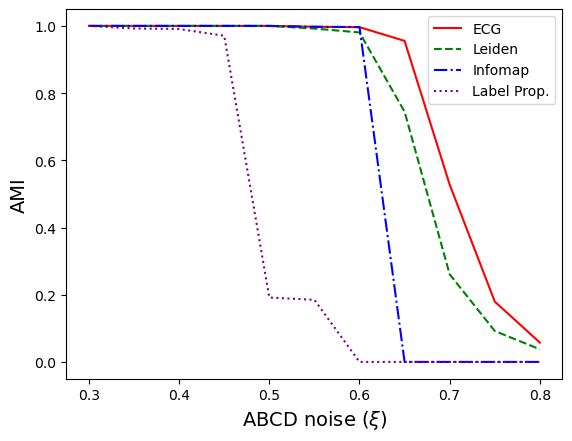

In [8]:
## mean AMI for various noise values
cls = ['red','green','blue','purple']
lt = ['-','--','-.',':']
D = df.groupby('xi', as_index=False).mean()
plt.plot(D.xi,D.ecg,lt[0],label='ECG',color=cls[0])
plt.plot(D.xi,D.leiden,lt[1],label='Leiden',color=cls[1])
plt.plot(D.xi,D.infomap,lt[2],label='Infomap',color=cls[2])
plt.plot(D.xi,D.lp,lt[3],label='Label Prop.',color=cls[3])
plt.xlabel(r'ABCD noise ($\xi$)', fontsize=14)
plt.ylabel('AMI', fontsize=14)
plt.legend()
#plt.savefig('abcd_study.eps')
plt.show()


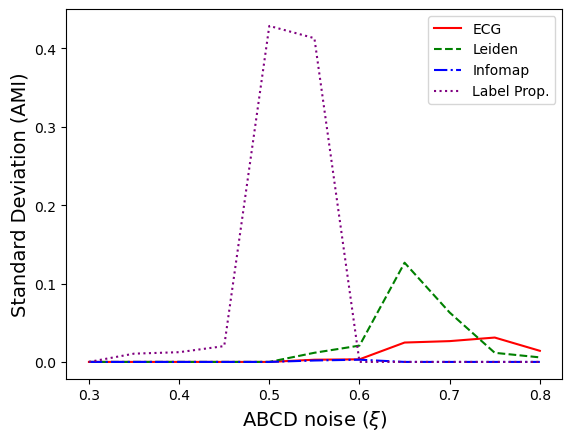

In [9]:
## Standard deviation AMI for various noise values
D = df.groupby('xi', as_index=False).std()
plt.plot(D.xi,D.ecg,lt[0],label='ECG',color=cls[0])
plt.plot(D.xi,D.leiden,lt[1],label='Leiden',color=cls[1])
plt.plot(D.xi,D.infomap,lt[2],label='Infomap',color=cls[2])
plt.plot(D.xi,D.lp,lt[3],label='Label Prop.',color=cls[3])
plt.xlabel(r'ABCD noise ($\xi$)', fontsize=14)
plt.ylabel('Standard Deviation (AMI)', fontsize=14)
plt.legend()
#plt.savefig('abcd_study_stdv.eps')
plt.show()


# (2) Julia implementation of ABCD

Here we show how to use the Julia version of ABCD inside a Python notebook.
To call ABCD directly in Julia, for example via command line, please consult: https://github.com/bkamins/ABCDGraphGenerator.jl

The following needs to be installed:
* The Julia language: ```https://julialang.org/downloads/```
* PyJulia: ```pip install julia```

To install the ABCD Julia package, open Julia REPL (the command line interface) and enter:
```
using Pkg
Pkg.add(url="https://github.com/bkamins/ABCDGraphGenerator.jl")
```


In [10]:
import julia               ## PyJulia, installed via: pip install julia
julia.install(quiet=True)  ## adding the path to the 'julia' executable may be needed
from julia.api import Julia 
jl = Julia(compiled_modules=False) ## needed on macOS (at least)
%load_ext julia.magic
from julia import Main as jl ## to get the Julia variables in Python code


Initializing Julia interpreter. This may take some time...


## (2.1) Generate a small ABCD graph in Julia

* We use the Julia package ```ABCDGraphGenerator```
* In the following cell, the first line indicates that the cell contains Julia code.
* This generates the objects ```edges``` and ```clusters```, the ABCD graph

The Julia API functions are:
 
* ABCDGraphGenerator.**sample_degrees**: sample degrees of vertices following power law
* ABCDGraphGenerator.**sample_communities**: sample community sizes following power law
* ABCDGraphGenerator.**ABCDParams**: type holding information about sampled degrees, sampled cluster sizes and required mode of ABCD graph generation
* ABCDGraphGenerator.**gen_graph**: ABCD graph generator that uses ABCDParams specification


In [11]:
%%julia
using Pkg
using ABCDGraphGenerator
using Random

## seeding
seed = 1
Random.seed!(seed)

## global parameters for the ABCD graph
xi = 0.2
n = 150

## degree sequence generation
gamma = 2.5
d_min = 8
d_max = 20
d_max_iter = 1000
degs = ABCDGraphGenerator.sample_degrees(gamma, d_min, d_max, n, d_max_iter)

## community sizes generation
beta = 1.5
c_min = 45
c_max = 75
c_max_iter = 1000
coms = ABCDGraphGenerator.sample_communities(beta, c_min, c_max, n, c_max_iter)
@assert sum(coms) == n

## generate ABCD-oo graph
p = ABCDGraphGenerator.ABCDParams(degs, coms, nothing, xi, false, false, false)
edges, clusters = ABCDGraphGenerator.gen_graph(p);


Below, we access Julia object via the```jl``` prefix.


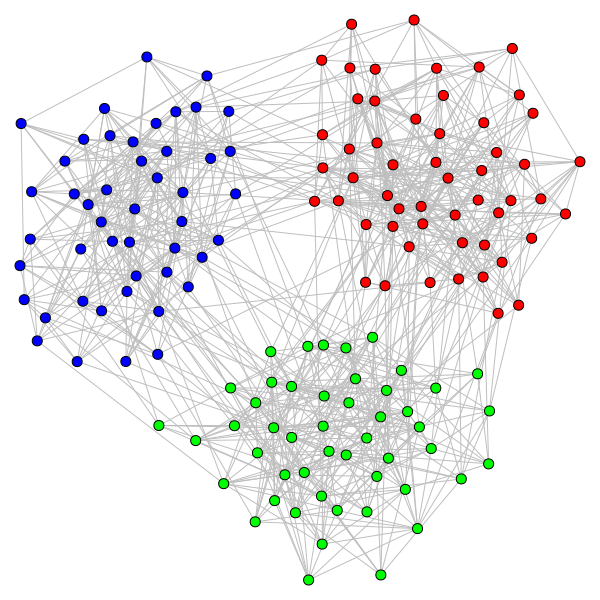

In [12]:
## Build igraph ABCD graph with communities 
Edges = list(jl.edges) ## 1-based in Julia
min_comm = 1
G = ig.Graph.TupleList(Edges)
G.vs['community'] = [int(jl.clusters[v-1])-1 for v in G.vs['name']]

## set node color
nc = max(jl.clusters)
my_pal = ig.drawing.colors.RainbowPalette(n=nc)
G.vs['color'] = [my_pal[i] for i in G.vs['community']]

## plot
ig.plot(G, bbox=(600,600), edge_color='grey', vertex_size=10)
